# Visualizing Directed Citation Network BFS Datasets

This notebook visualizes the new directed citation network graphs (Scale-Free, GN, GNR) generated via NetworkX for the NAR Processor.


In [29]:
import sys
import os

# Add project root to path so we can import from src/
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Import workspace utility
from src.utils.graph_generation import get_dataset

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")

Project root: /home/marko/projects/gdg/nar-experiments
PyTorch version: 2.8.0+cu128


## 1. Load Datasets

Load validation (ER, n=16), test (all generators × sizes), and training (ER, n=4–16, with hints) splits.

In [30]:
from src.utils.config import get_cfg_defaults
from src.utils.graph_generation import get_dataset
import os

cfg = get_cfg_defaults()
cfg.DATA.DIRECTED = True
cfg.DATA.TEST.GRAPH_GENERATOR = ['scale_free', 'gn', 'gnr']
cfg.DATA.TEST.NICKNAME = ['sf_16', 'gn_16', 'gnr_16']
cfg.DATA.TEST.NUM_SAMPLES = 10
cfg.DATA.TEST.GENERATOR_PARAMS = [
    {'n': 16, 'alpha': 0.41, 'beta': 0.54, 'gamma': 0.05, 'connected': True},
    {'n': 16},
    {'n': 16, 'p': 0.5}
]

DATA_ROOT = os.path.join(project_root, "data", "salsaclrs")
test_datasets = get_dataset('test', cfg=cfg)
print(f"\nTest sets ({len(test_datasets)} generators):")
for name, ds in test_datasets.items():
    print(f"  {name}: {len(ds)} samples")


2026-03-12 02:21:35.632 | INFO     | src.utils.graph_generation:get_dataset:155 - Using custom generator params from config for test: [{'n': 16, 'alpha': 0.41, 'beta': 0.54, 'gamma': 0.05, 'connected': True}, {'n': 16}, {'n': 16, 'p': 0.5}]


Loading bfs dataset for split: test...

Test sets (3 generators):
  sf_16: 10 samples
  gn_16: 10 samples
  gnr_16: 10 samples


In [31]:
# Inspect a single sample from the sf_16 set
sample = test_datasets['sf_16'][0]
print("=== Scale-Free (sf_16) sample ===")
print(f"Type: {type(sample).__name__}")
print(f"edge_index shape: {sample.edge_index.shape}")
print(f"Number of nodes: {sample.s.shape[0]}")
print(f"Number of edges (directed): {sample.edge_index.shape[1]}")
print(f"Source node: {sample.s.argmax().item()}")
print(f"BFS tree edges (pi>0.5): {(sample.pi > 0.5).sum().item()}")

train_sample = test_datasets['gn_16'][0]
print("\n=== GN (gn_16) sample ===")
print(f"edge_index shape: {train_sample.edge_index.shape}")


=== Scale-Free (sf_16) sample ===
Type: CLRSData
edge_index shape: torch.Size([2, 64])
Number of nodes: 16
Number of edges (directed): 64
Source node: 15
BFS tree edges (pi>0.5): 16

=== GN (gn_16) sample ===
edge_index shape: torch.Size([2, 46])


## 2. Helper Functions

Utilities to convert SALSA-CLRS `CLRSData` objects to NetworkX graphs and draw them with BFS tree overlays.

In [32]:
def parse_bfs_sample(data):
    """Extract graph structure and BFS results from a CLRSData sample.
    
    Returns:
        G: undirected NetworkX graph
        source: source node index
        bfs_tree_edges: set of (u, v) tuples — directed predecessor edges (child -> parent)
        num_nodes: number of nodes
    """
    edge_index = data.edge_index.numpy()
    num_nodes = data.s.shape[0]
    
    # Build undirected graph
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    edges = set()
    for i in range(edge_index.shape[1]):
        u, v = edge_index[0, i], edge_index[1, i]
        edges.add((min(u, v), max(u, v)))
    G.add_edges_from(edges)
    
    # Source node
    source = data.s.argmax().item()
    
    # BFS tree edges from pi: edges where pi == 1.0
    # pi is [E] — one-hot mask over edge_index
    # edge_index[:, i] = (src, dst) where pi[i] == 1 means dst's predecessor is src
    pi = data.pi.numpy()
    bfs_tree_edges = []
    for i in range(len(pi)):
        if pi[i] > 0.5:
            u, v = edge_index[0, i], edge_index[1, i]
            # Skip self-loops (source points to itself)
            if u != v:
                bfs_tree_edges.append((u, v))
    
    return G, source, bfs_tree_edges, num_nodes


def parse_bfs_hints(data, step):
    """Extract BFS state at a given hint step from a training sample.
    
    Returns:
        reached_nodes: set of node indices reached by step t
        tree_edges: list of (u, v) predecessor edges active at step t
    """
    edge_index = data.edge_index.numpy()
    
    # reach_h: [N, T] — node reachability at each step
    reach = data.reach_h[:, step].numpy()
    reached_nodes = set(np.where(reach > 0.5)[0])
    
    # pi_h: [E, T] — predecessor tree edges at each step  
    pi = data.pi_h[:, step].numpy()
    tree_edges = []
    for i in range(len(pi)):
        if pi[i] > 0.5:
            u, v = edge_index[0, i], edge_index[1, i]
            if u != v:
                tree_edges.append((u, v))
    
    return reached_nodes, tree_edges


def draw_bfs_graph(data, ax=None, title=None, layout="spring", seed=42):
    """Visualize a SALSA-CLRS BFS sample showing the graph and BFS tree.
    
    Args:
        data: CLRSData sample
        ax: matplotlib axes (created if None)
        title: optional title string
        layout: 'kamada_kawai', 'spring', or 'spectral'
        seed: random seed for spring layout
    """
    G, source, bfs_tree_edges, num_nodes = parse_bfs_sample(data)
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Layout
    if layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G)
    elif layout == "spring":
        pos = nx.spring_layout(G, seed=seed, k=2.0/np.sqrt(num_nodes))
    else:
        pos = nx.spectral_layout(G)
    
    # Draw all edges (light gray)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#d0d0d0", width=1.0, alpha=0.8)
    
    # Draw BFS tree edges as directed arrows (child → parent via predecessor)
    if bfs_tree_edges:
        tree_G = nx.DiGraph()
        tree_G.add_nodes_from(G.nodes())
        tree_G.add_edges_from(bfs_tree_edges)  # (src, dst) = predecessor edges
        nx.draw_networkx_edges(
            tree_G, pos, edgelist=bfs_tree_edges, ax=ax,
            edge_color="#e63946", width=2.5, alpha=0.9,
            arrows=True, arrowstyle='-|>', arrowsize=15,
            connectionstyle='arc3,rad=0.1', min_source_margin=10, min_target_margin=10
        )
    
    # Determine which nodes are in the BFS tree
    tree_nodes = set()
    tree_nodes.add(source)
    for u, v in bfs_tree_edges:
        tree_nodes.add(u)
        tree_nodes.add(v)
    
    unreachable = [n for n in G.nodes() if n not in tree_nodes]
    reachable = [n for n in G.nodes() if n in tree_nodes and n != source]
    
    # Draw unreachable nodes
    if unreachable:
        nx.draw_networkx_nodes(G, pos, nodelist=unreachable, ax=ax,
                               node_color="#bbb", node_size=300, edgecolors="#888", linewidths=1.0)
    
    # Draw reachable nodes
    if reachable:
        nx.draw_networkx_nodes(G, pos, nodelist=reachable, ax=ax,
                               node_color="#457b9d", node_size=300, edgecolors="#1d3557", linewidths=1.5)
    
    # Draw source node (larger, distinct color)
    nx.draw_networkx_nodes(G, pos, nodelist=[source], ax=ax,
                           node_color="#f4a261", node_size=500, edgecolors="#e76f51", 
                           linewidths=2.5, node_shape="*")
    
    # Node labels
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color="white", font_weight="bold")
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='#f4a261', 
               markeredgecolor='#e76f51', markersize=15, label='Source'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#457b9d',
               markeredgecolor='#1d3557', markersize=10, label='Reachable'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='#bbb',
               markeredgecolor='#888', markersize=10, label='Unreachable'),
        Line2D([0], [0], color='#e63946', linewidth=2.5, label='BFS tree edge (\u2192 parent)'),
        Line2D([0], [0], color='#d0d0d0', linewidth=1.0, label='Graph edge'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=7, framealpha=0.9)
    
    # Title
    if title is None:
        title = f"N={num_nodes}, E={G.number_of_edges()}, src={source}, steps={data.length}"
    ax.set_title(title, fontsize=10)
    ax.axis('off')
    
    return pos  # return layout for reuse




## 3. Scale-Free Graph Visualization

Visualize one directed sample from the Scale-Free generator.

Nodes: 16
Directed edges: 40
Source node: 15
BFS tree edges: 15


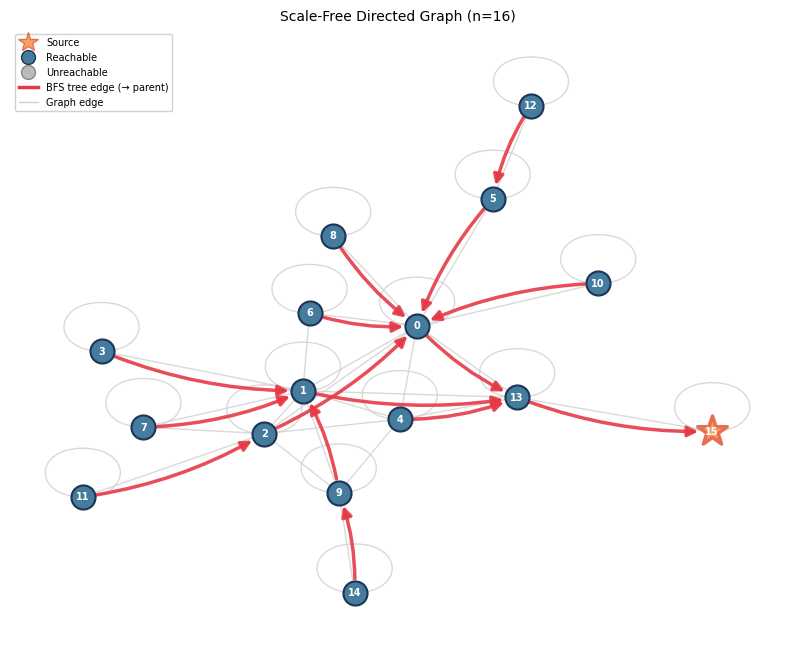

In [33]:
sample_sf = test_datasets['sf_16'][0]
G_sf, src_sf, tree_sf, n_sf = parse_bfs_sample(sample_sf)
print(f"Nodes: {n_sf}")
print(f"Directed edges: {G_sf.number_of_edges()}")
print(f"Source node: {src_sf}")
print(f"BFS tree edges: {len(tree_sf)}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
draw_bfs_graph(sample_sf, ax=ax, title="Scale-Free Directed Graph (n=16)", layout="spring", seed=42)
plt.show()


## 4. GN Graph Visualization

Visualize one directed sample from the GN (Growing Network) generator.

Nodes: 16
Directed edges: 31
Source node: 1


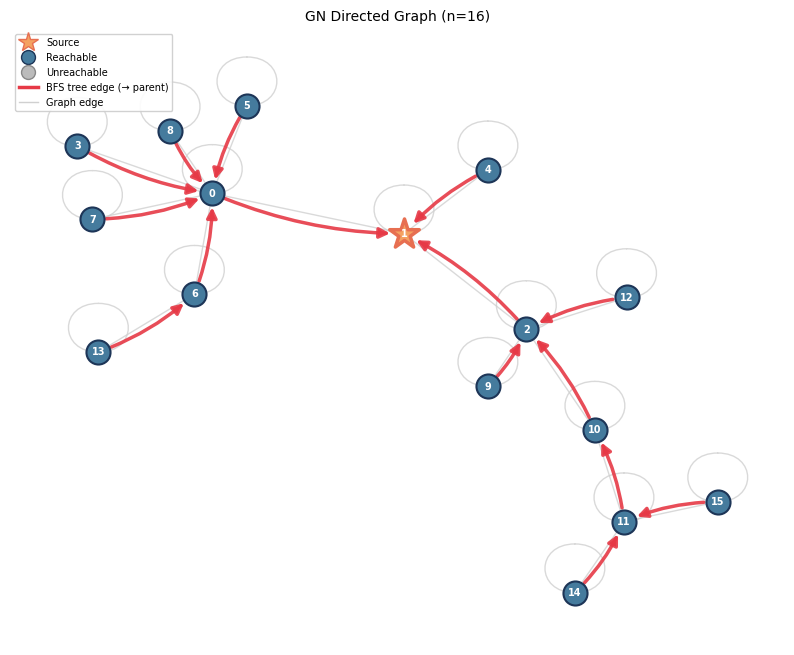

In [34]:
sample_gn = test_datasets['gn_16'][0]
G_gn, src_gn, tree_gn, n_gn = parse_bfs_sample(sample_gn)
print(f"Nodes: {n_gn}")
print(f"Directed edges: {G_gn.number_of_edges()}")
print(f"Source node: {src_gn}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
draw_bfs_graph(sample_gn, ax=ax, title="GN Directed Graph (n=16)", layout="spring", seed=42)
plt.show()


## 5. GNR Graph Visualization

Visualize one directed sample from the GNR (Growing Network with Redirection) generator.

Nodes: 16
Directed edges: 31
Source node: 0


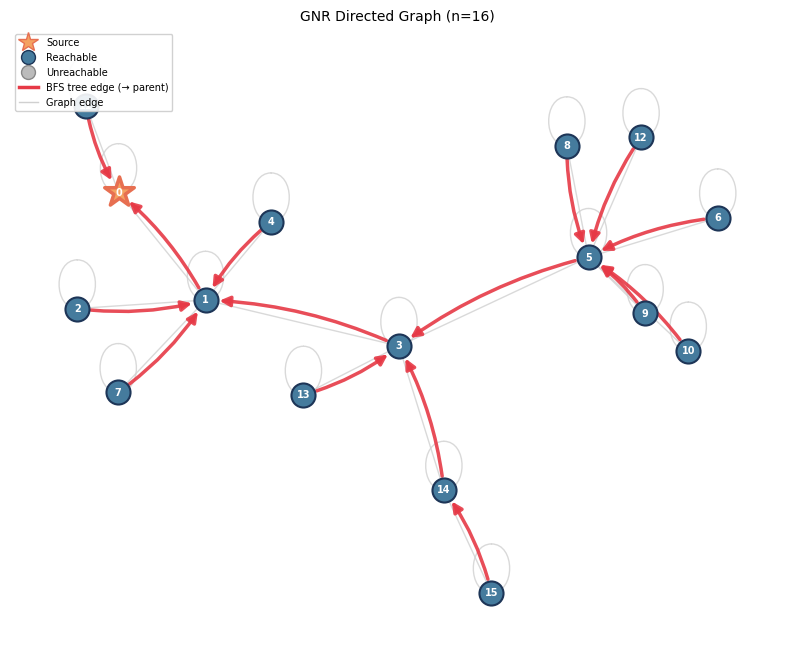

In [35]:
sample_gnr = test_datasets['gnr_16'][0]
G_gnr, src_gnr, tree_gnr, n_gnr = parse_bfs_sample(sample_gnr)
print(f"Nodes: {n_gnr}")
print(f"Directed edges: {G_gnr.number_of_edges()}")
print(f"Source node: {src_gnr}")

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
draw_bfs_graph(sample_gnr, ax=ax, title="GNR Directed Graph (n=16)", layout="spring", seed=42)
plt.show()
